In [1]:
!pip install -q ultralytics==8.4.115 huggingface_hub pyyaml requests

import hashlib
import json
import math
import os
import random
import re
import shutil
import tarfile
import time
from concurrent.futures import ThreadPoolExecutor, as_completed
from pathlib import Path

import cv2
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import requests
import torch
import ultralytics
import yaml

from IPython.display import display
from google.colab import drive, userdata
from huggingface_hub import HfApi, get_token, hf_hub_url, login
from sklearn.model_selection import StratifiedKFold
from tqdm.auto import tqdm
from ultralytics import YOLO, settings

os.environ["WANDB_DISABLED"] = "true"
settings.update({"wandb": False})

print("Ultralytics:", ultralytics.__version__)
print("PyTorch:", torch.__version__)
print(
    "GPU:",
    torch.cuda.get_device_name(0) if torch.cuda.is_available() else "Not available",
)
if torch.cuda.is_available():
    print(
        "CUDA memory:",
        f"{torch.cuda.get_device_properties(0).total_memory / 2**30:.1f} GiB",
    )

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.5/45.5 kB 3.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 80.9 MB/s eta 0:00:00
Creating new Ultralytics Settings v0.0.7 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Ultralytics: 8.4.115
PyTorch: 2.11.0+cu128
GPU: NVIDIA L4
CUDA memory: 22.0 GiB


In [2]:
drive.mount("/content/drive")





REPO_ID = "hunglc007/ThyroidXL"
REPO_TYPE = "dataset"



DRIVE_PROJECT_ROOT = Path(
    "/content/drive/MyDrive/ThyroidXL_Publication_OneFold"
)

EXPECTED_REPO_REVISION = (
    "b15fe293bd74f1a8a4f05bf88bcdf06a1934125f"
)
REPO_REVISION = EXPECTED_REPO_REVISION

SEED = 42
N_FOLDS = 5
FOLD_INDEX = 1

CACHE_ROOT = Path("/content/thyroidxl_remote_cache")
CACHE_ROOT.mkdir(parents=True, exist_ok=True)

CACHE_ARCHIVE_DIR = DRIVE_PROJECT_ROOT / "cache_archives"
CACHE_ARCHIVE_DIR.mkdir(parents=True, exist_ok=True)


YOLO_DATASET_ROOT = Path("/content/thyroidxl_yolo_seg_fold1")
YOLO_RUN_ROOT = Path("/content/thyroidxl_yolo_runs")



CANONICAL_MODEL_DIR = (
    DRIVE_PROJECT_ROOT / "Models" / "YOLOv8sSeg"
)
CANONICAL_RESULTS_DIR = (
    DRIVE_PROJECT_ROOT / "results" / "YOLOv8sSeg"
)
CANONICAL_MODEL_DIR.mkdir(parents=True, exist_ok=True)
CANONICAL_RESULTS_DIR.mkdir(parents=True, exist_ok=True)




CNN_CHECKPOINT_DIR = (
    DRIVE_PROJECT_ROOT / "Models" / "MobileNetV3"
)
cnn_candidates = sorted(
    CNN_CHECKPOINT_DIR.glob("*_development_best.pt")
)

def torch_load_full(path, map_location="cpu"):
    try:
        return torch.load(
            path,
            map_location=map_location,
            weights_only=False,
        )
    except TypeError:
        return torch.load(
            path,
            map_location=map_location,
        )

if cnn_candidates:
    CNN_CHECKPOINT = cnn_candidates[-1]
    cnn_meta = torch_load_full(CNN_CHECKPOINT)

    if str(cnn_meta.get("dataset", "")) != "ThyroidXL":
        raise RuntimeError(
            f"Expected a ThyroidXL CNN checkpoint, found "
            f"{cnn_meta.get('dataset')!r}: {CNN_CHECKPOINT}"
        )

    observed_revision = str(
        cnn_meta.get("dataset_revision", "")
    )
    if observed_revision != EXPECTED_REPO_REVISION:
        raise RuntimeError(
            "MobileNet and YOLO dataset revisions disagree: "
            f"MobileNet={observed_revision!r}, "
            f"YOLO={EXPECTED_REPO_REVISION!r}"
        )

    if int(cnn_meta.get("patient_split_seed", -1)) != SEED:
        raise RuntimeError("MobileNet / YOLO patient-split seed mismatch.")
    if int(cnn_meta.get("n_folds", -1)) != N_FOLDS:
        raise RuntimeError("MobileNet / YOLO n_folds mismatch.")
    if int(cnn_meta.get("fold_index", -1)) != FOLD_INDEX:
        raise RuntimeError("MobileNet / YOLO fold mismatch.")

    print("Cross-checked dataset/split metadata against:")
    print(" ", CNN_CHECKPOINT)
else:
    CNN_CHECKPOINT = None
    print(
        "MobileNet development checkpoint not found locally; "
        "continuing with the publication-pinned ThyroidXL revision."
    )

assert SEED == 42
assert N_FOLDS == 5
assert FOLD_INDEX == 1


try:
    from huggingface_hub import login
except ImportError as exc:
    raise RuntimeError(
        "huggingface_hub.login is unavailable. Re-run the first install/import "
        "cell so the pinned huggingface_hub package is installed."
    ) from exc

HF_TOKEN = None
try:
    HF_TOKEN = userdata.get("HF_TOKEN")
except Exception:
    HF_TOKEN = None

if not HF_TOKEN:
    HF_TOKEN = get_token()

if HF_TOKEN:
    login(
        token=HF_TOKEN,
        add_to_git_credential=False,
    )
else:
    print(
        "No HF_TOKEN secret or saved login was found.\n"
        "An interactive Hugging Face login prompt will open now.\n"
        "Paste a READ token from the account that has accepted access to ThyroidXL."
    )
    login(add_to_git_credential=False)
    HF_TOKEN = get_token()

if not HF_TOKEN:
    raise RuntimeError(
        "No Hugging Face token is available after login. "
        "Use a READ token from an account with ThyroidXL access."
    )



if not re.fullmatch(r"[0-9a-f]{40}", REPO_REVISION):
    raise RuntimeError(
        f"Expected an immutable 40-character git revision, got {REPO_REVISION!r}"
    )

print("Hugging Face authentication: OK")
print("Repository:", REPO_ID)
print("Pinned revision:", REPO_REVISION)
print("Project root:", DRIVE_PROJECT_ROOT)
print("Seed:", SEED)
print("Fold:", FOLD_INDEX, "of", N_FOLDS)


Mounted at /content/drive
Cross-checked dataset/split metadata against:
  /content/drive/MyDrive/ThyroidXL_Publication_OneFold/Models/MobileNetV3/mobilenetv3_thyroidxl_modelB_v2_patientfold1_512_seed42_development_best.pt
No HF_TOKEN secret or saved login was found.
An interactive Hugging Face login prompt will open now.
Paste a READ token from the account that has accepted access to ThyroidXL.


Hugging Face authentication: OK
Repository: hunglc007/ThyroidXL
Pinned revision: b15fe293bd74f1a8a4f05bf88bcdf06a1934125f
Project root: /content/drive/MyDrive/ThyroidXL_Publication_OneFold
Seed: 42
Fold: 1 of 5


In [3]:




EXPECTED_TRAIN_IMAGES = 9541
EXPECTED_TRAIN_PATIENTS = 3354
EXPECTED_TRAIN_BENIGN_PATIENTS = 2477
EXPECTED_TRAIN_MALIGNANT_PATIENTS = 877

EXPECTED_FOLD_TRAIN_IMAGES = 7684
EXPECTED_FOLD_VAL_IMAGES = 1857
EXPECTED_FOLD_TRAIN_PATIENTS = 2683
EXPECTED_FOLD_VAL_PATIENTS = 671


EXPECTED_FOLD_TRAIN_BENIGN_IMAGES = 5689
EXPECTED_FOLD_TRAIN_MALIGNANT_IMAGES = 1995
EXPECTED_FOLD_VAL_BENIGN_IMAGES = 1363
EXPECTED_FOLD_VAL_MALIGNANT_IMAGES = 494

IMAGE_SIZE = 640
BATCH_SIZE = 8
EPOCHS = 50



PATIENCE_EPOCHS = EPOCHS

OPTIMIZER = "AdamW"
LEARNING_RATE = 5e-4
FINAL_LR_FRACTION = 0.10
WEIGHT_DECAY = 5e-4
WARMUP_EPOCHS = 3.0


DEGREES_ROTATION = 7.5
TRANSLATE_IMG = 0.03
SCALE_IMG = 0.10
SHEAR_IMG = 2.0
PERSPECTIVE_IMG = 0.0

FLIP_LR = 0.50
FLIP_UD = 0.0


HSV_H = 0.0
HSV_S = 0.0
HSV_V = 0.08

MOSAIC_PROBABILITY = 0.0
MIXUP_PROBABILITY = 0.0
CUTMIX_PROBABILITY = 0.0
COPY_PASTE_PROBABILITY = 0.0


MASK_RATIO = 2
OVERLAP_MASK = True

VALIDATION_CONFIDENCE = 0.001
VALIDATION_NMS_IOU = 0.70
VALIDATION_MAX_DETECTIONS = 300

PRIMARY_SELECTION_METRIC = "mask_map50_95"
SELECTION_SOURCE = "training_time_validation_mask_map50_95"

RUN_NAME = (
    f"thyroidxl_yolov8s_seg_2class_patientfold{FOLD_INDEX}_"
    f"{IMAGE_SIZE}_seed{SEED}_50ep"
)

print("Run:", RUN_NAME)
print("Architecture: YOLOv8s-seg")
print("Classes: 0=benign, 1=malignant")
print("Image size:", IMAGE_SIZE)
print("Epochs:", EPOCHS)
print("Batch size:", BATCH_SIZE)
print("LR:", LEARNING_RATE)
print("Mosaic:", MOSAIC_PROBABILITY)
print("Mask ratio:", MASK_RATIO)
print("Selection metric:", PRIMARY_SELECTION_METRIC)

Run: thyroidxl_yolov8s_seg_2class_patientfold1_640_seed42_50ep
Architecture: YOLOv8s-seg
Classes: 0=benign, 1=malignant
Image size: 640
Epochs: 50
Batch size: 8
LR: 0.0005
Mosaic: 0.0
Mask ratio: 2
Selection metric: mask_map50_95


In [4]:




AUTH_HEADERS = {
    "Authorization": f"Bearer {HF_TOKEN}",
    "User-Agent": "ThyroidXL-YOLOv8sSeg/1.0",
}

def local_remote_path(repo_path):
    repo_path = str(repo_path).replace("\\", "/").lstrip("/")
    return CACHE_ROOT / Path(repo_path)

def cached_remote_file(repo_path, max_attempts=20):
    repo_path = str(repo_path).replace("\\", "/").lstrip("/")
    destination = local_remote_path(repo_path)
    destination.parent.mkdir(parents=True, exist_ok=True)

    if destination.is_file() and destination.stat().st_size > 0:
        return destination

    url = hf_hub_url(
        repo_id=REPO_ID,
        filename=repo_path,
        repo_type=REPO_TYPE,
        revision=REPO_REVISION,
    )

    partial = destination.with_name(destination.name + ".part")

    for attempt in range(1, max_attempts + 1):
        try:
            with requests.get(
                url,
                headers=AUTH_HEADERS,
                stream=True,
                allow_redirects=True,
                timeout=(30, 300),
            ) as response:
                if response.status_code == 429:
                    retry_after = response.headers.get("Retry-After")
                    wait = float(retry_after) if retry_after else min(60.0, 2.0 * attempt)
                    print(f"HTTP 429 for {repo_path}; sleeping {wait:.1f}s")
                    time.sleep(wait)
                    continue

                response.raise_for_status()

                with partial.open("wb") as f:
                    for chunk in response.iter_content(chunk_size=1024 * 1024):
                        if chunk:
                            f.write(chunk)

            if partial.stat().st_size <= 0:
                raise RuntimeError("Downloaded zero-byte file.")

            partial.replace(destination)
            return destination

        except Exception:
            partial.unlink(missing_ok=True)
            if attempt == max_attempts:
                raise
            time.sleep(min(30.0, 1.5 * attempt))

    raise RuntimeError(f"Could not fetch {repo_path}")


annotations_path = cached_remote_file("train/train_annotations.json")
print("Train annotations:", annotations_path)
print("No test path has been requested.")

Train annotations: /content/thyroidxl_remote_cache/train/train_annotations.json
No test path has been requested.


In [5]:




with annotations_path.open("r", encoding="utf-8") as f:
    train_annotations = json.load(f)

for required_key in ("images", "annotations"):
    if required_key not in train_annotations:
        raise RuntimeError(f"Missing COCO key: {required_key}")

images_records = train_annotations["images"]
annotation_records = train_annotations["annotations"]
category_records = train_annotations.get("categories", [])

category_id_to_name = {
    item["id"]: str(item.get("name", "")).strip()
    for item in category_records
    if isinstance(item, dict) and "id" in item
}

def patient_id_from_filename(filename):
    stem = Path(filename).stem
    match = re.match(r"^(\d+)(?:_|$)", stem)
    if match is None:
        raise ValueError(f"Cannot derive patient ID from filename: {filename}")
    return str(int(match.group(1)))

def category_to_binary(category_id):
    name = str(category_id_to_name.get(category_id, "")).strip().lower()
    if "benign" in name:
        return 0
    if "malignant" in name:
        return 1
    if category_id in (0, 1):
        return int(category_id)
    if str(category_id).strip() in {"0", "1"}:
        return int(category_id)
    return None

image_id_to_filename = {}
rows = []

for item in images_records:
    image_id = item["id"]
    filename = Path(str(item["file_name"])).name

    if image_id in image_id_to_filename:
        raise RuntimeError(f"Duplicate image ID: {image_id}")

    image_id_to_filename[image_id] = filename
    rows.append(
        {
            "image_id": image_id,
            "filename": filename,
            "patient_id": patient_id_from_filename(filename),
        }
    )

by_image = {}
for ann in annotation_records:
    image_id = ann.get("image_id")
    category_id = ann.get("category_id")
    if image_id in image_id_to_filename and category_id is not None:
        by_image.setdefault(image_id, set()).add(category_id)

labels = {}
bad = []

for image_id, filename in image_id_to_filename.items():
    values = {
        category_to_binary(cid)
        for cid in by_image.get(image_id, set())
    }
    values.discard(None)

    if len(values) != 1:
        bad.append((filename, sorted(map(str, by_image.get(image_id, set())))))
    else:
        labels[image_id] = next(iter(values))

if bad:
    raise RuntimeError(
        f"Could not derive one benign/malignant diagnosis for every image. "
        f"Examples: {bad[:10]}"
    )

train_frame = pd.DataFrame(rows)
train_frame["label"] = train_frame["image_id"].map(labels).astype(int)

assert len(train_frame) == EXPECTED_TRAIN_IMAGES
assert train_frame["patient_id"].nunique() == EXPECTED_TRAIN_PATIENTS


patient_label_frame = (
    train_frame[["patient_id", "label"]]
    .drop_duplicates()
    .sort_values("patient_id", key=lambda x: x.astype(int))
    .reset_index(drop=True)
)

if patient_label_frame.groupby("patient_id")["label"].nunique().max() != 1:
    raise RuntimeError("A patient has inconsistent diagnosis labels.")

assert len(patient_label_frame) == EXPECTED_TRAIN_PATIENTS

patient_counts = patient_label_frame["label"].value_counts().sort_index().to_dict()
assert patient_counts == {
    0: EXPECTED_TRAIN_BENIGN_PATIENTS,
    1: EXPECTED_TRAIN_MALIGNANT_PATIENTS,
}


patients_for_split = patient_label_frame.copy()
patients_for_split["fold"] = -1

skf = StratifiedKFold(
    n_splits=N_FOLDS,
    shuffle=True,
    random_state=SEED,
)

for fold_zero_based, (_, val_indices) in enumerate(
    skf.split(patients_for_split["patient_id"], patients_for_split["label"])
):
    patients_for_split.loc[val_indices, "fold"] = fold_zero_based + 1

patient_to_fold = patients_for_split.set_index("patient_id")["fold"].to_dict()
train_frame["fold"] = train_frame["patient_id"].map(patient_to_fold).astype(int)

train_df = (
    train_frame[train_frame["fold"] != FOLD_INDEX]
    .sort_values(["patient_id", "filename"])
    .reset_index(drop=True)
)

val_df = (
    train_frame[train_frame["fold"] == FOLD_INDEX]
    .sort_values(["patient_id", "filename"])
    .reset_index(drop=True)
)

train_patients = set(train_df["patient_id"])
val_patients = set(val_df["patient_id"])

assert not (train_patients & val_patients)
assert len(train_df) == EXPECTED_FOLD_TRAIN_IMAGES
assert len(val_df) == EXPECTED_FOLD_VAL_IMAGES
assert len(train_patients) == EXPECTED_FOLD_TRAIN_PATIENTS
assert len(val_patients) == EXPECTED_FOLD_VAL_PATIENTS

assert train_df["label"].value_counts().sort_index().to_dict() == {
    0: EXPECTED_FOLD_TRAIN_BENIGN_IMAGES,
    1: EXPECTED_FOLD_TRAIN_MALIGNANT_IMAGES,
}
assert val_df["label"].value_counts().sort_index().to_dict() == {
    0: EXPECTED_FOLD_VAL_BENIGN_IMAGES,
    1: EXPECTED_FOLD_VAL_MALIGNANT_IMAGES,
}

print("Training images:", len(train_df))
print("Training patients:", len(train_patients))
print("Training image classes:", train_df["label"].value_counts().sort_index().to_dict())
print()
print("Validation images:", len(val_df))
print("Validation patients:", len(val_patients))
print("Validation image classes:", val_df["label"].value_counts().sort_index().to_dict())
print()
print("Patient overlap:", len(train_patients & val_patients))


Training images: 7684
Training patients: 2683
Training image classes: {0: 5689, 1: 1995}

Validation images: 1857
Validation patients: 671
Validation image classes: {0: 1363, 1: 494}

Patient overlap: 0


In [6]:







CACHE_ARCHIVE = (
    CACHE_ARCHIVE_DIR
    / f"thyroidxl_train_pairs_{REPO_REVISION[:12]}.tar"
)

required_filenames = sorted(train_frame["filename"].unique())
assert len(required_filenames) == EXPECTED_TRAIN_IMAGES

def pair_paths(filename):
    return (
        CACHE_ROOT / "train" / "images" / filename,
        CACHE_ROOT / "train" / "masks" / filename,
    )

def pair_is_cached(filename):
    image_path, mask_path = pair_paths(filename)
    return (
        image_path.is_file()
        and image_path.stat().st_size > 0
        and mask_path.is_file()
        and mask_path.stat().st_size > 0
    )

complete_before = sum(pair_is_cached(name) for name in required_filenames)

print("Cached pairs before restore:", f"{complete_before:,}/{EXPECTED_TRAIN_IMAGES:,}")
print("Drive archive:", CACHE_ARCHIVE)

if complete_before < EXPECTED_TRAIN_IMAGES and CACHE_ARCHIVE.is_file():
    print("Restoring existing CNN cache archive into /content...")
    with tarfile.open(CACHE_ARCHIVE, "r") as tar:
        tar.extractall(CACHE_ROOT)

complete_after_restore = sum(pair_is_cached(name) for name in required_filenames)
missing_names = [name for name in required_filenames if not pair_is_cached(name)]

print("Pairs after restore:", f"{complete_after_restore:,}/{EXPECTED_TRAIN_IMAGES:,}")

PRECACHE_WORKERS = 4

def fetch_pair(filename):
    image = cached_remote_file(f"train/images/{filename}")
    mask = cached_remote_file(f"train/masks/{filename}")
    return filename, image, mask

if missing_names:
    print(f"Downloading {len(missing_names):,} missing pairs...")
    failures = []

    with ThreadPoolExecutor(max_workers=PRECACHE_WORKERS) as executor:
        futures = {
            executor.submit(fetch_pair, filename): filename
            for filename in missing_names
        }

        with tqdm(total=len(futures), desc="Caching ThyroidXL pairs", unit="pair") as pbar:
            for future in as_completed(futures):
                filename = futures[future]
                try:
                    future.result()
                except Exception as exc:
                    failures.append((filename, repr(exc)))
                finally:
                    pbar.update(1)

    if failures:
        raise RuntimeError(
            f"{len(failures)} cache failures. First examples: {failures[:10]}"
        )


failures = []

for filename in tqdm(required_filenames, desc="Verifying image/mask pairs", unit="pair"):
    image_path, mask_path = pair_paths(filename)

    if not pair_is_cached(filename):
        failures.append((filename, "missing"))
        continue

    image = cv2.imread(str(image_path), cv2.IMREAD_COLOR)
    mask = cv2.imread(str(mask_path), cv2.IMREAD_GRAYSCALE)

    if image is None:
        failures.append((filename, "unreadable image"))
    elif mask is None:
        failures.append((filename, "unreadable mask"))
    elif image.shape[:2] != mask.shape[:2]:
        failures.append((filename, "shape mismatch"))
    elif not (mask > 0).any():
        failures.append((filename, "empty mask"))

if failures:
    raise RuntimeError(
        f"Cache integrity failure in {len(failures)} pairs. "
        f"First examples: {failures[:10]}"
    )

assert sum(pair_is_cached(name) for name in required_filenames) == EXPECTED_TRAIN_IMAGES

print("✅ All official-training image/mask pairs are local and valid.")
print("✅ Official test remains untouched.")

Cached pairs before restore: 0/9,541
Drive archive: /content/drive/MyDrive/ThyroidXL_Publication_OneFold/cache_archives/thyroidxl_train_pairs_b15fe293bd74.tar
Pairs after restore: 0/9,541


Caching ThyroidXL pairs:   0%|          | 0/9541 [00:00<?, ?pair/s]

Verifying image/mask pairs:   0%|          | 0/9541 [00:00<?, ?pair/s]

✅ All official-training image/mask pairs are local and valid.
✅ Official test remains untouched.


In [7]:









REBUILD_YOLO_DATASET = True

if REBUILD_YOLO_DATASET and YOLO_DATASET_ROOT.exists():
    shutil.rmtree(YOLO_DATASET_ROOT)

for split in ("train", "val"):
    (YOLO_DATASET_ROOT / "images" / split).mkdir(parents=True, exist_ok=True)
    (YOLO_DATASET_ROOT / "labels" / split).mkdir(parents=True, exist_ok=True)

def link_or_copy(source, destination):
    destination = Path(destination)
    if destination.exists() or destination.is_symlink():
        destination.unlink()

    try:
        os.symlink(source, destination)
    except OSError:
        shutil.copy2(source, destination)

def largest_external_contour(mask_binary):
    contours, _ = cv2.findContours(
        mask_binary.astype(np.uint8),
        cv2.RETR_EXTERNAL,
        cv2.CHAIN_APPROX_SIMPLE,
    )

    contours = [
        contour
        for contour in contours
        if contour is not None and len(contour) >= 3 and cv2.contourArea(contour) > 0
    ]

    if not contours:
        raise RuntimeError("No valid contour found.")

    contours = sorted(contours, key=cv2.contourArea, reverse=True)
    return contours[0], contours

def polygon_reconstruction_iou(mask_binary, polygon_xy):
    reconstruction = np.zeros_like(mask_binary, dtype=np.uint8)
    cv2.fillPoly(
        reconstruction,
        [np.round(polygon_xy).astype(np.int32).reshape(-1, 1, 2)],
        1,
    )

    gt = mask_binary.astype(bool)
    pred = reconstruction.astype(bool)
    inter = np.logical_and(gt, pred).sum()
    union = np.logical_or(gt, pred).sum()
    return float(inter / union) if union else 0.0

def simplify_contour_with_fidelity(mask_binary, contour):
    perimeter = cv2.arcLength(contour, closed=True)


    epsilon_fractions = (0.0020, 0.0010, 0.0005, 0.00025, 0.0)

    best = None

    for fraction in epsilon_fractions:
        if fraction == 0.0:
            candidate = contour
        else:
            candidate = cv2.approxPolyDP(
                contour,
                epsilon=fraction * perimeter,
                closed=True,
            )

        points = candidate.reshape(-1, 2)

        if len(points) < 3:
            continue

        iou = polygon_reconstruction_iou(mask_binary, points)
        best = (points, iou, fraction)

        if iou >= 0.98:
            break

    if best is None:
        raise RuntimeError("Could not construct a valid segmentation polygon.")

    return best

def build_yolo_split(frame, split):
    records = []

    for row in tqdm(
        frame.itertuples(index=False),
        total=len(frame),
        desc=f"Building YOLO {split}",
        unit="img",
    ):
        filename = str(row.filename)
        class_id = int(row.label)

        source_image, source_mask = pair_paths(filename)
        image = cv2.imread(str(source_image), cv2.IMREAD_COLOR)
        mask = cv2.imread(str(source_mask), cv2.IMREAD_GRAYSCALE)

        if image is None or mask is None:
            raise RuntimeError(f"Unreadable cached pair: {filename}")

        mask_binary = (mask > 0).astype(np.uint8)
        h, w = mask_binary.shape

        main_contour, all_contours = largest_external_contour(mask_binary)

        main_component_mask = np.zeros_like(mask_binary)
        cv2.fillPoly(main_component_mask, [main_contour], 1)

        retained_fraction = float(
            np.logical_and(mask_binary > 0, main_component_mask > 0).sum()
            / max(1, (mask_binary > 0).sum())
        )

        points, reconstruction_iou, epsilon_fraction = (
            simplify_contour_with_fidelity(mask_binary, main_contour)
        )


        normalized = points.astype(np.float64)
        normalized[:, 0] = np.clip(normalized[:, 0] / float(w), 0.0, 1.0)
        normalized[:, 1] = np.clip(normalized[:, 1] / float(h), 0.0, 1.0)

        if len(normalized) < 3:
            raise RuntimeError(f"Polygon has <3 points: {filename}")

        yolo_line = (
            f"{class_id} "
            + " ".join(f"{value:.8f}" for value in normalized.reshape(-1))
        )

        target_image = YOLO_DATASET_ROOT / "images" / split / filename
        target_label = YOLO_DATASET_ROOT / "labels" / split / f"{Path(filename).stem}.txt"

        link_or_copy(source_image, target_image)
        target_label.write_text(yolo_line + "\n", encoding="utf-8")

        records.append(
            {
                "split": split,
                "filename": filename,
                "patient_id": str(row.patient_id),
                "class_id": class_id,
                "height": h,
                "width": w,
                "mask_fraction": float(mask_binary.mean()),
                "external_components": len(all_contours),
                "largest_component_retained_fraction": retained_fraction,
                "polygon_points": len(normalized),
                "polygon_reconstruction_iou": reconstruction_iou,
                "epsilon_fraction": epsilon_fraction,
            }
        )

    return pd.DataFrame(records)

train_polygon_audit = build_yolo_split(train_df, "train")
val_polygon_audit = build_yolo_split(val_df, "val")
polygon_audit = pd.concat([train_polygon_audit, val_polygon_audit], ignore_index=True)


all_stems = pd.Series([Path(x).stem for x in polygon_audit["filename"]])
if all_stems.duplicated().any():
    raise RuntimeError("Duplicate image stems detected; YOLO label mapping would be ambiguous.")


bad_component = polygon_audit[
    polygon_audit["largest_component_retained_fraction"] < 0.95
]
bad_polygon = polygon_audit[
    polygon_audit["polygon_reconstruction_iou"] < 0.95
]

if not bad_component.empty:
    display(bad_component.head(20))
    raise RuntimeError(
        f"{len(bad_component)} masks have <95% foreground in the largest component."
    )

if not bad_polygon.empty:
    display(bad_polygon.head(20))
    raise RuntimeError(
        f"{len(bad_polygon)} mask polygons reconstruct with IoU <0.95."
    )

assert len(train_polygon_audit) == EXPECTED_FOLD_TRAIN_IMAGES
assert len(val_polygon_audit) == EXPECTED_FOLD_VAL_IMAGES

AUDIT_CSV = CANONICAL_RESULTS_DIR / f"{RUN_NAME}_polygon_conversion_audit.csv"
polygon_audit.to_csv(AUDIT_CSV, index=False)

print("YOLO dataset:", YOLO_DATASET_ROOT)
print()
print("Polygon conversion summary:")
display(
    polygon_audit[
        [
            "mask_fraction",
            "external_components",
            "largest_component_retained_fraction",
            "polygon_points",
            "polygon_reconstruction_iou",
        ]
    ].describe()
)
print("Saved audit:", AUDIT_CSV)

Building YOLO train:   0%|          | 0/7684 [00:00<?, ?img/s]

Building YOLO val:   0%|          | 0/1857 [00:00<?, ?img/s]

YOLO dataset: /content/thyroidxl_yolo_seg_fold1

Polygon conversion summary:


,mask_fraction,external_components,largest_component_retained_fraction,polygon_points,polygon_reconstruction_iou
count,9541.000000,9541.0,9541.0,9541.000000,9541.000000
mean,0.079293,1.0,1.0,23.242637,0.995281
std,0.081450,0.0,0.0,7.338315,0.001282
min,0.005653,1.0,1.0,12.000000,0.989451
25%,0.027513,1.0,1.0,19.000000,0.994512
50%,0.048275,1.0,1.0,21.000000,0.995312
75%,0.096599,1.0,1.0,25.000000,0.996091
max,0.652018,1.0,1.0,79.000000,1.000000


Saved audit: /content/drive/MyDrive/ThyroidXL_Publication_OneFold/results/YOLOv8sSeg/thyroidxl_yolov8s_seg_2class_patientfold1_640_seed42_50ep_polygon_conversion_audit.csv


path: /content/thyroidxl_yolo_seg_fold1
train: /content/thyroidxl_yolo_fold1_train.txt
val: /content/thyroidxl_yolo_fold1_val.txt
nc: 2
names:
- benign
- malignant

✅ Ultralytics image->label mapping audit passed.


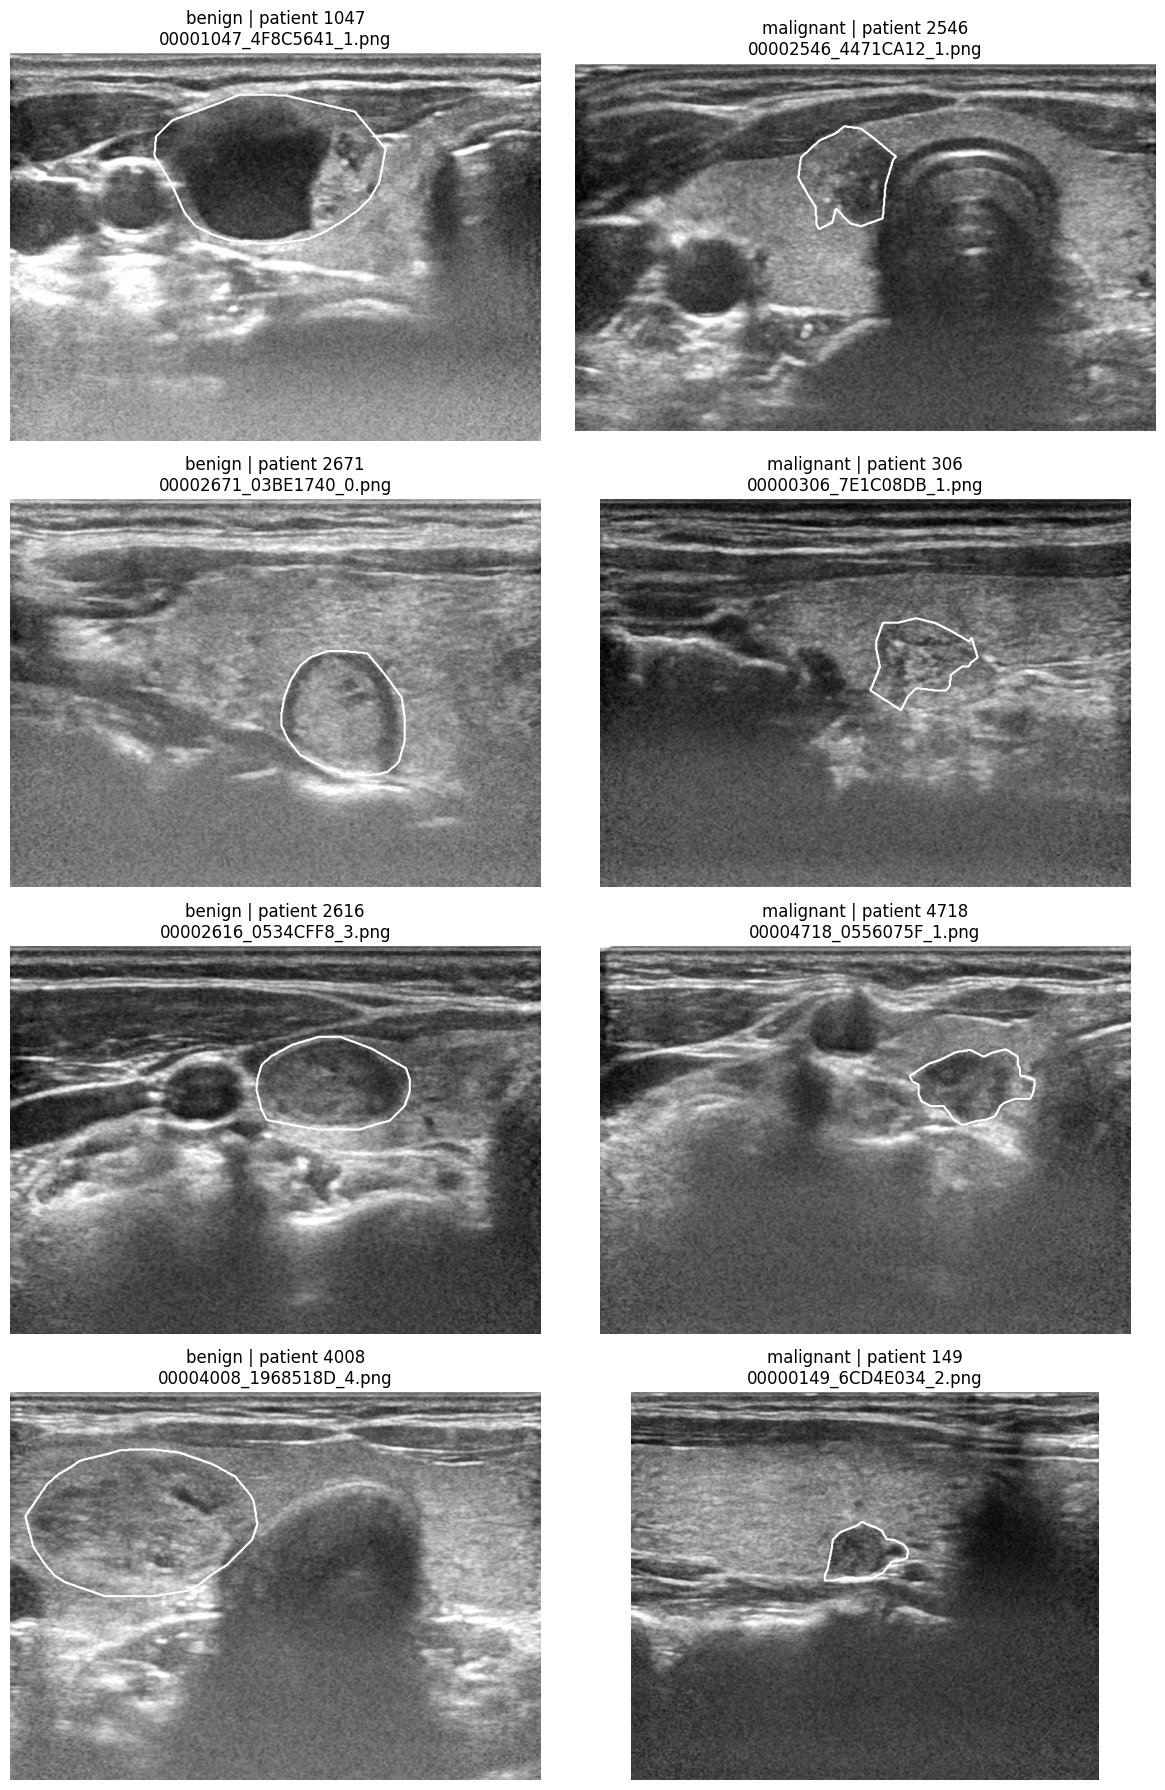

✅ Same Fold 1 patient split as CNN.
✅ Every training/validation image has exactly one class-aware expert-mask label file.
✅ Official test is absent from the YAML and has not been accessed.


In [8]:




TRAIN_IMAGE_DIR = YOLO_DATASET_ROOT / "images" / "train"
TRAIN_LABEL_DIR = YOLO_DATASET_ROOT / "labels" / "train"
VAL_IMAGE_DIR = YOLO_DATASET_ROOT / "images" / "val"
VAL_LABEL_DIR = YOLO_DATASET_ROOT / "labels" / "val"

train_images = sorted(p for p in TRAIN_IMAGE_DIR.iterdir() if p.is_file() or p.is_symlink())
val_images = sorted(p for p in VAL_IMAGE_DIR.iterdir() if p.is_file() or p.is_symlink())

assert len(train_images) == EXPECTED_FOLD_TRAIN_IMAGES
assert len(val_images) == EXPECTED_FOLD_VAL_IMAGES

assert {p.stem for p in train_images} == {p.stem for p in TRAIN_LABEL_DIR.glob("*.txt")}
assert {p.stem for p in val_images} == {p.stem for p in VAL_LABEL_DIR.glob("*.txt")}
assert not ({p.name for p in train_images} & {p.name for p in val_images})

TRAIN_LIST_PATH = Path("/content/thyroidxl_yolo_fold1_train.txt")
VAL_LIST_PATH = Path("/content/thyroidxl_yolo_fold1_val.txt")





TRAIN_LIST_PATH.write_text(
    "\n".join(str(path.absolute()) for path in train_images),
    encoding="utf-8",
)
VAL_LIST_PATH.write_text(
    "\n".join(str(path.absolute()) for path in val_images),
    encoding="utf-8",
)

DATA_YAML_PATH = Path("/content/thyroidxl_yolov8s_seg_fold1.yaml")

data_yaml = {
    "path": str(YOLO_DATASET_ROOT),
    "train": str(TRAIN_LIST_PATH),
    "val": str(VAL_LIST_PATH),
    "nc": 2,
    "names": ["benign", "malignant"],
}

with DATA_YAML_PATH.open("w", encoding="utf-8") as f:
    yaml.safe_dump(data_yaml, f, sort_keys=False)

print(DATA_YAML_PATH.read_text(encoding="utf-8"))




from ultralytics.data.utils import img2label_paths, check_det_dataset

train_list_entries = [
    line.strip()
    for line in TRAIN_LIST_PATH.read_text(encoding="utf-8").splitlines()
    if line.strip()
]
val_list_entries = [
    line.strip()
    for line in VAL_LIST_PATH.read_text(encoding="utf-8").splitlines()
    if line.strip()
]

assert len(train_list_entries) == EXPECTED_FOLD_TRAIN_IMAGES
assert len(val_list_entries) == EXPECTED_FOLD_VAL_IMAGES



expected_images_fragment = f"{os.sep}thyroidxl_yolo_seg_fold1{os.sep}images{os.sep}"
if not all(expected_images_fragment in path for path in train_list_entries + val_list_entries):
    raise RuntimeError(
        "The YOLO image list does not preserve the dataset /images/ tree. "
        "Do not resolve image symlinks."
    )

mapped_train_labels = [Path(path) for path in img2label_paths(train_list_entries)]
mapped_val_labels = [Path(path) for path in img2label_paths(val_list_entries)]

missing_mapped_train = [str(path) for path in mapped_train_labels if not path.is_file()]
missing_mapped_val = [str(path) for path in mapped_val_labels if not path.is_file()]

if missing_mapped_train or missing_mapped_val:
    raise RuntimeError(
        "Ultralytics image->label mapping failed. "
        f"Missing train labels={len(missing_mapped_train)}, "
        f"missing val labels={len(missing_mapped_val)}. "
        f"Examples={(missing_mapped_train + missing_mapped_val)[:10]}"
    )

assert {path.resolve() for path in mapped_train_labels} == {
    path.resolve() for path in TRAIN_LABEL_DIR.glob("*.txt")
}
assert {path.resolve() for path in mapped_val_labels} == {
    path.resolve() for path in VAL_LABEL_DIR.glob("*.txt")
}



possible_cache_paths = [
    YOLO_DATASET_ROOT / "labels" / "train.cache",
    YOLO_DATASET_ROOT / "labels" / "val.cache",
    TRAIN_LABEL_DIR / "train.cache",
    VAL_LABEL_DIR / "val.cache",
    TRAIN_LIST_PATH.with_suffix(".cache"),
    VAL_LIST_PATH.with_suffix(".cache"),
    Path(str(TRAIN_LIST_PATH) + ".cache"),
    Path(str(VAL_LIST_PATH) + ".cache"),
]

for cache_path in possible_cache_paths:
    if cache_path.exists():
        cache_path.unlink()
        print("Deleted stale Ultralytics cache:", cache_path)


checked_data = check_det_dataset(str(DATA_YAML_PATH))
assert int(checked_data["nc"]) == 2
assert list(checked_data["names"].values()) == ["benign", "malignant"]

print("✅ Ultralytics image->label mapping audit passed.")


rng = np.random.default_rng(SEED + 1000)
fig, axes = plt.subplots(4, 2, figsize=(12, 18))

for col, class_id in enumerate((0, 1)):
    class_rows = train_df[train_df["label"] == class_id].copy()
    patient_ids = class_rows["patient_id"].drop_duplicates().to_numpy()
    chosen_patients = rng.choice(patient_ids, size=4, replace=False)

    for row_idx, patient_id in enumerate(chosen_patients):
        row = class_rows[class_rows["patient_id"] == patient_id].iloc[0]
        image_path, mask_path = pair_paths(row["filename"])
        image = cv2.cvtColor(cv2.imread(str(image_path)), cv2.COLOR_BGR2RGB)
        mask = cv2.imread(str(mask_path), cv2.IMREAD_GRAYSCALE) > 0

        axes[row_idx, col].imshow(image)
        axes[row_idx, col].contour(mask, levels=[0.5], colors="white", linewidths=1.5)
        axes[row_idx, col].set_title(
            f"{'benign' if class_id == 0 else 'malignant'} | "
            f"patient {patient_id}\n{row['filename']}"
        )
        axes[row_idx, col].axis("off")

plt.tight_layout()
plt.show()

print("✅ Same Fold 1 patient split as CNN.")
print("✅ Every training/validation image has exactly one class-aware expert-mask label file.")
print("✅ Official test is absent from the YAML and has not been accessed.")

In [9]:








torch.cuda.empty_cache()

model = YOLO("yolov8s-seg.pt")

training_results = model.train(
    data=str(DATA_YAML_PATH),

    epochs=EPOCHS,
    imgsz=IMAGE_SIZE,
    batch=BATCH_SIZE,
    nbs=64,

    project=str(YOLO_RUN_ROOT),
    name=RUN_NAME,
    exist_ok=False,

    optimizer=OPTIMIZER,
    lr0=LEARNING_RATE,
    lrf=FINAL_LR_FRACTION,
    weight_decay=WEIGHT_DECAY,
    cos_lr=True,
    warmup_epochs=WARMUP_EPOCHS,

    degrees=DEGREES_ROTATION,
    translate=TRANSLATE_IMG,
    scale=SCALE_IMG,
    shear=SHEAR_IMG,
    perspective=PERSPECTIVE_IMG,

    fliplr=FLIP_LR,
    flipud=FLIP_UD,

    hsv_h=HSV_H,
    hsv_s=HSV_S,
    hsv_v=HSV_V,


    mosaic=MOSAIC_PROBABILITY,
    close_mosaic=0,
    mixup=MIXUP_PROBABILITY,
    cutmix=CUTMIX_PROBABILITY,
    copy_paste=COPY_PASTE_PROBABILITY,

    mask_ratio=MASK_RATIO,
    overlap_mask=OVERLAP_MASK,

    patience=PATIENCE_EPOCHS,

    amp=True,
    workers=8,
    cache=False,
    rect=False,

    seed=SEED,
    deterministic=True,
    device=0,

    val=True,
    plots=True,
    save=True,


    save_period=1,
)

print("Training complete.")
print("Run directory:", model.trainer.save_dir)

New https://pypi.org/project/ultralytics/8.4.128 available 😃 Update with 'pip install -U ultralytics'
Ultralytics 8.4.115 🚀 Python-3.13.15 torch-2.11.0+cu128 CUDA:0 (NVIDIA L4, 22563MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=8, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=False, classes=None, close_mosaic=0, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=True, cutmix=0.0, data=/content/thyroidxl_yolov8s_seg_fold1.yaml, degrees=7.5, deterministic=True, device=0, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.0, hsv_s=0.0, hsv_v=0.08, imgsz=640, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.0005, lrf=0.1, mask_ratio=2, max_det=300, mixup=0.0,

Mask mAP50-95 column: metrics/mAP50-95(M)
Mask mAP50 column: metrics/mAP50(M)
Box mAP50-95 column: metrics/mAP50-95(B)
Saved epoch checkpoints: 50

Prespecified selected training epoch: 16
Selected checkpoint: /content/thyroidxl_yolo_runs/thyroidxl_yolov8s_seg_2class_patientfold1_640_seed42_50ep/weights/epoch15.pt
Training-time validation mask mAP50-95: 0.5468
Training-time validation mask mAP50: 0.8564


,epoch,checkpoint_epoch_zero_based,metrics/mAP50-95(M),metrics/mAP50(M),metrics/mAP50-95(B)
0,16,15,0.54676,0.85636,0.55181
1,12,11,0.53800,0.84142,0.53831
2,23,22,0.53695,0.84058,0.54416
3,18,17,0.53090,0.82963,0.53266
4,14,13,0.53074,0.83791,0.53940
5,27,26,0.53012,0.82623,0.53347
6,17,16,0.52623,0.83597,0.52847
7,24,23,0.52590,0.82534,0.53014
8,42,41,0.52460,0.82538,0.52711
9,13,12,0.52458,0.83349,0.53528


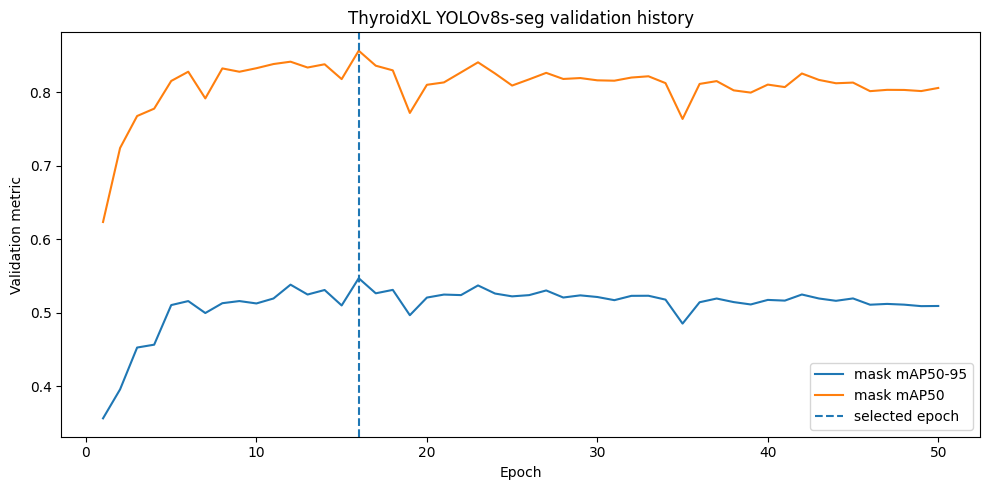

Persisted training history: /content/drive/MyDrive/ThyroidXL_Publication_OneFold/results/YOLOv8sSeg/thyroidxl_yolov8s_seg_2class_patientfold1_640_seed42_50ep_results.csv


In [10]:














RUN_DIRECTORY = Path(model.trainer.save_dir)
WEIGHTS_DIRECTORY = RUN_DIRECTORY / "weights"
RESULTS_CSV = RUN_DIRECTORY / "results.csv"

ULTRALYTICS_BEST_CHECKPOINT = WEIGHTS_DIRECTORY / "best.pt"
LAST_CHECKPOINT = WEIGHTS_DIRECTORY / "last.pt"

assert RUN_DIRECTORY.is_dir()
assert WEIGHTS_DIRECTORY.is_dir()
assert RESULTS_CSV.is_file()
assert ULTRALYTICS_BEST_CHECKPOINT.is_file()
assert LAST_CHECKPOINT.is_file()

saved_epoch_checkpoints = sorted(
    WEIGHTS_DIRECTORY.glob("epoch*.pt"),
    key=lambda path: int(re.search(r"epoch(\d+)", path.stem).group(1)),
)

if not saved_epoch_checkpoints:
    raise RuntimeError(
        "No epoch checkpoints were saved. save_period=1 is required for "
        "mask-mAP50-95 checkpoint selection."
    )

history = pd.read_csv(RESULTS_CSV)
history.columns = [column.strip() for column in history.columns]

def find_metric_column(columns, required_tokens):
    for column in columns:
        normalized = column.lower().replace(" ", "")
        if all(
            token.lower().replace(" ", "") in normalized
            for token in required_tokens
        ):
            return column
    raise KeyError(
        f"Could not find metric column containing {required_tokens}. "
        f"Columns={list(columns)}"
    )

MASK_MAP5095_COLUMN = find_metric_column(
    history.columns,
    ["metrics/", "map50-95", "(m)"],
)
MASK_MAP50_COLUMN = find_metric_column(
    history.columns,
    ["metrics/", "map50(m)"],
)
BOX_MAP5095_COLUMN = find_metric_column(
    history.columns,
    ["metrics/", "map50-95", "(b)"],
)

if "epoch" not in history.columns:
    raise RuntimeError(
        f"Ultralytics results.csv has no epoch column: {list(history.columns)}"
    )



training_history = history[
    pd.to_numeric(history["epoch"], errors="coerce").between(1, EPOCHS)
].copy()

if training_history.empty:
    raise RuntimeError("No genuine training-epoch rows were found in results.csv.")

training_history["checkpoint_epoch_zero_based"] = (
    pd.to_numeric(training_history["epoch"], errors="raise").astype(int) - 1
)

history_ranked = (
    training_history
    .sort_values(
        [MASK_MAP5095_COLUMN, MASK_MAP50_COLUMN, BOX_MAP5095_COLUMN],
        ascending=[False, False, False],
        kind="mergesort",
    )
    .reset_index(drop=True)
)

SELECTED_HISTORY_ROW = history_ranked.iloc[0]
SELECTED_HISTORY_EPOCH_ZERO_BASED = int(
    SELECTED_HISTORY_ROW["checkpoint_epoch_zero_based"]
)
SELECTED_HISTORY_CHECKPOINT = (
    WEIGHTS_DIRECTORY / f"epoch{SELECTED_HISTORY_EPOCH_ZERO_BASED}.pt"
)

if not SELECTED_HISTORY_CHECKPOINT.is_file():
    raise RuntimeError(
        "The segmentation-best history row does not have its required saved "
        f"checkpoint: {SELECTED_HISTORY_CHECKPOINT}"
    )

print("Mask mAP50-95 column:", MASK_MAP5095_COLUMN)
print("Mask mAP50 column:", MASK_MAP50_COLUMN)
print("Box mAP50-95 column:", BOX_MAP5095_COLUMN)
print("Saved epoch checkpoints:", len(saved_epoch_checkpoints))
print()
print(
    "Prespecified selected training epoch:",
    int(SELECTED_HISTORY_ROW["epoch"]),
)
print(
    "Selected checkpoint:",
    SELECTED_HISTORY_CHECKPOINT,
)
print(
    "Training-time validation mask mAP50-95:",
    f"{float(SELECTED_HISTORY_ROW[MASK_MAP5095_COLUMN]):.4f}",
)
print(
    "Training-time validation mask mAP50:",
    f"{float(SELECTED_HISTORY_ROW[MASK_MAP50_COLUMN]):.4f}",
)

display(
    history_ranked[
        [
            "epoch",
            "checkpoint_epoch_zero_based",
            MASK_MAP5095_COLUMN,
            MASK_MAP50_COLUMN,
            BOX_MAP5095_COLUMN,
        ]
    ].head(15)
)


PERSISTED_RESULTS_CSV = (
    CANONICAL_RESULTS_DIR / f"{RUN_NAME}_results.csv"
)
shutil.copy2(RESULTS_CSV, PERSISTED_RESULTS_CSV)


fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(
    training_history["epoch"],
    training_history[MASK_MAP5095_COLUMN],
    label="mask mAP50-95",
)
ax.plot(
    training_history["epoch"],
    training_history[MASK_MAP50_COLUMN],
    label="mask mAP50",
)
ax.axvline(
    int(SELECTED_HISTORY_ROW["epoch"]),
    linestyle="--",
    label="selected epoch",
)
ax.set_xlabel("Epoch")
ax.set_ylabel("Validation metric")
ax.set_title("ThyroidXL YOLOv8s-seg validation history")
ax.legend()
plt.tight_layout()
plt.show()

print("Persisted training history:", PERSISTED_RESULTS_CSV)


In [11]:











def validation_record(checkpoint_name, checkpoint_path, metrics):
    record = {
        "checkpoint_name": checkpoint_name,
        "checkpoint_path": str(checkpoint_path),
        "box_precision": float(metrics.box.mp),
        "box_recall": float(metrics.box.mr),
        "box_map50": float(metrics.box.map50),
        "box_map50_95": float(metrics.box.map),
        "mask_precision": float(metrics.seg.mp),
        "mask_recall": float(metrics.seg.mr),
        "mask_map50": float(metrics.seg.map50),
        "mask_map50_95": float(metrics.seg.map),
    }

    per_class = getattr(metrics.seg, "maps", None)
    if per_class is not None and len(per_class) >= 2:
        record["benign_mask_map50_95"] = float(per_class[0])
        record["malignant_mask_map50_95"] = float(per_class[1])

    return record

candidate_specs = [
    ("selected_history_epoch", SELECTED_HISTORY_CHECKPOINT),
    ("ultralytics_best_composite", ULTRALYTICS_BEST_CHECKPOINT),
    ("last_epoch", LAST_CHECKPOINT),
]


unique_specs = []
seen_paths = set()
for name, path in candidate_specs:
    resolved = str(path.resolve())
    if resolved not in seen_paths:
        unique_specs.append((name, path))
        seen_paths.add(resolved)

CHECKPOINT_VALIDATION_DIRECTORY = Path(
    "/content/thyroidxl_yolo_checkpoint_revalidation"
)

checkpoint_records = []

for index, (candidate_name, candidate_path) in enumerate(unique_specs, start=1):
    candidate_model = YOLO(str(candidate_path))

    metrics = candidate_model.val(
        data=str(DATA_YAML_PATH),
        split="val",
        imgsz=IMAGE_SIZE,
        batch=BATCH_SIZE,
        rect=False,
        conf=VALIDATION_CONFIDENCE,
        iou=VALIDATION_NMS_IOU,
        max_det=VALIDATION_MAX_DETECTIONS,
        device=0,
        workers=8,
        augment=False,
        plots=False,
        project=str(CHECKPOINT_VALIDATION_DIRECTORY),
        name=f"{index:02d}_{candidate_name}",
        exist_ok=True,
        verbose=False,
    )

    record = validation_record(
        candidate_name,
        candidate_path,
        metrics,
    )
    checkpoint_records.append(record)

    print(
        f"[{index}/{len(unique_specs)}] {candidate_name}: "
        f"mask mAP50-95={record['mask_map50_95']:.4f}, "
        f"mask mAP50={record['mask_map50']:.4f}"
    )

checkpoint_table = pd.DataFrame(checkpoint_records)

CHECKPOINT_METRICS_CSV = (
    CANONICAL_RESULTS_DIR
    / f"{RUN_NAME}_checkpoint_validation_metrics.csv"
)
checkpoint_table.to_csv(CHECKPOINT_METRICS_CSV, index=False)

display(checkpoint_table)


SELECTED_CHECKPOINT = SELECTED_HISTORY_CHECKPOINT
SELECTED_ROW = checkpoint_table[
    checkpoint_table["checkpoint_name"] == "selected_history_epoch"
].iloc[0]


logged_mask_map5095 = float(SELECTED_HISTORY_ROW[MASK_MAP5095_COLUMN])
revalidated_mask_map5095 = float(SELECTED_ROW["mask_map50_95"])
metric_difference = abs(logged_mask_map5095 - revalidated_mask_map5095)

print()
print("FINAL SELECTED CHECKPOINT:", SELECTED_CHECKPOINT)
print(
    "Logged/revalidated mask mAP50-95:",
    f"{logged_mask_map5095:.4f} / {revalidated_mask_map5095:.4f}",
)
print("Absolute difference:", f"{metric_difference:.6f}")

if metric_difference > 0.01:
    print(
        "WARNING: the revalidated metric differs by >0.01 from the "
        "training-time metric. Keep the selected checkpoint fixed, but inspect "
        "the run before using it in the publication."
    )


Ultralytics 8.4.115 🚀 Python-3.13.15 torch-2.11.0+cu128 CUDA:0 (NVIDIA L4, 22563MiB)
YOLOv8s-seg summary (fused): 86 layers, 11,780,374 parameters, 0 gradients, 39.9 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 3761.6±783.6 MB/s, size: 576.2 KB)
val: Scanning /content/thyroidxl_yolo_seg_fold1/labels/val.cache... 1857 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 1857/1857 708.1Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95)     Mask(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 233/233 15.1it/s 15.5s
                   all       1857       1857      0.764      0.834      0.857      0.554      0.766      0.836       0.86       0.55
Speed: 0.7ms preprocess, 4.1ms inference, 0.0ms loss, 1.2ms postprocess per image
[1/3] selected_history_epoch: mask mAP50-95=0.5505, mask mAP50=0.8604
Ultralytics 8.4.115 🚀 Python-3.13.15 torch-2.11.0+cu128 CUDA:0 (NVIDIA L4, 22563MiB)
YOLOv8s-seg summary (fused): 86 layers, 11,780

,checkpoint_name,checkpoint_path,box_precision,box_recall,box_map50,box_map50_95,mask_precision,mask_recall,mask_map50,mask_map50_95,benign_mask_map50_95,malignant_mask_map50_95
0,selected_history_epoch,/content/thyroidxl_yolo_runs/thyroidxl_yolov8s...,0.764107,0.833522,0.857312,0.553619,0.766436,0.835825,0.860402,0.550455,0.634003,0.466907
1,ultralytics_best_composite,/content/thyroidxl_yolo_runs/thyroidxl_yolov8s...,0.764107,0.833522,0.857312,0.553619,0.766436,0.835825,0.860402,0.550455,0.634003,0.466907
2,last_epoch,/content/thyroidxl_yolo_runs/thyroidxl_yolov8s...,0.798343,0.820775,0.819699,0.522518,0.799664,0.822154,0.824755,0.524115,0.614636,0.433595



FINAL SELECTED CHECKPOINT: /content/thyroidxl_yolo_runs/thyroidxl_yolov8s_seg_2class_patientfold1_640_seed42_50ep/weights/epoch15.pt
Logged/revalidated mask mAP50-95: 0.5468 / 0.5505
Absolute difference: 0.003695


In [12]:




selected_model = YOLO(str(SELECTED_CHECKPOINT))

SELECTED_VALIDATION_DIRECTORY = RUN_DIRECTORY / "selected_checkpoint_validation"

selected_standard_metrics = selected_model.val(
    data=str(DATA_YAML_PATH),
    split="val",
    imgsz=IMAGE_SIZE,
    batch=BATCH_SIZE,
    rect=False,
    conf=VALIDATION_CONFIDENCE,
    iou=VALIDATION_NMS_IOU,
    max_det=VALIDATION_MAX_DETECTIONS,
    device=0,
    workers=8,
    augment=False,
    plots=True,
    project=str(SELECTED_VALIDATION_DIRECTORY),
    name="standard",
    exist_ok=True,
    verbose=True,
)

SELECTED_STANDARD_RECORD = validation_record(
    "selected_standard",
    SELECTED_CHECKPOINT,
    selected_standard_metrics,
)

print("Selected standard validation:")
display(pd.DataFrame([SELECTED_STANDARD_RECORD]))

RUN_TTA_COMPARISON = False
TTA_RECORD = None
TTA_RECOMMENDED = False
TTA_ERROR = None

if RUN_TTA_COMPARISON:
    try:
        tta_metrics = selected_model.val(
            data=str(DATA_YAML_PATH),
            split="val",
            imgsz=IMAGE_SIZE,
            batch=BATCH_SIZE,
            rect=False,
            conf=VALIDATION_CONFIDENCE,
            iou=VALIDATION_NMS_IOU,
            max_det=VALIDATION_MAX_DETECTIONS,
            device=0,
            workers=8,
            augment=True,
            plots=False,
            project=str(SELECTED_VALIDATION_DIRECTORY),
            name="tta",
            exist_ok=True,
            verbose=False,
        )

        TTA_RECORD = validation_record(
            "selected_tta",
            SELECTED_CHECKPOINT,
            tta_metrics,
        )

        TTA_RECOMMENDED = bool(
            TTA_RECORD["mask_map50_95"]
            > SELECTED_STANDARD_RECORD["mask_map50_95"]
        )

        print("Validation-only TTA comparison:")
        display(
            pd.DataFrame(
                [
                    SELECTED_STANDARD_RECORD,
                    TTA_RECORD,
                ]
            )
        )
        print("TTA recommended by mask mAP50-95:", TTA_RECOMMENDED)

    except Exception as exc:
        TTA_ERROR = repr(exc)
        print("TTA comparison failed; standard inference remains default.")
        print(TTA_ERROR)

Ultralytics 8.4.115 🚀 Python-3.13.15 torch-2.11.0+cu128 CUDA:0 (NVIDIA L4, 22563MiB)
YOLOv8s-seg summary (fused): 86 layers, 11,780,374 parameters, 0 gradients, 39.9 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 3956.3±738.7 MB/s, size: 575.4 KB)
val: Scanning /content/thyroidxl_yolo_seg_fold1/labels/val.cache... 1857 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 1857/1857 519.3Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95)     Mask(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 233/233 13.1it/s 17.8s
                   all       1857       1857      0.764      0.834      0.857      0.554      0.766      0.836       0.86       0.55
                benign       1363       1363      0.807      0.929       0.93       0.64      0.806      0.927       0.93      0.634
             malignant        494        494      0.721      0.738      0.785      0.468      0.727      0.744      0.791      0.467
Speed: 0.7ms prep

,checkpoint_name,checkpoint_path,box_precision,box_recall,box_map50,box_map50_95,mask_precision,mask_recall,mask_map50,mask_map50_95,benign_mask_map50_95,malignant_mask_map50_95
0,selected_standard,/content/thyroidxl_yolo_runs/thyroidxl_yolov8s...,0.764107,0.833522,0.857312,0.553619,0.766436,0.835825,0.860402,0.550455,0.634003,0.466907


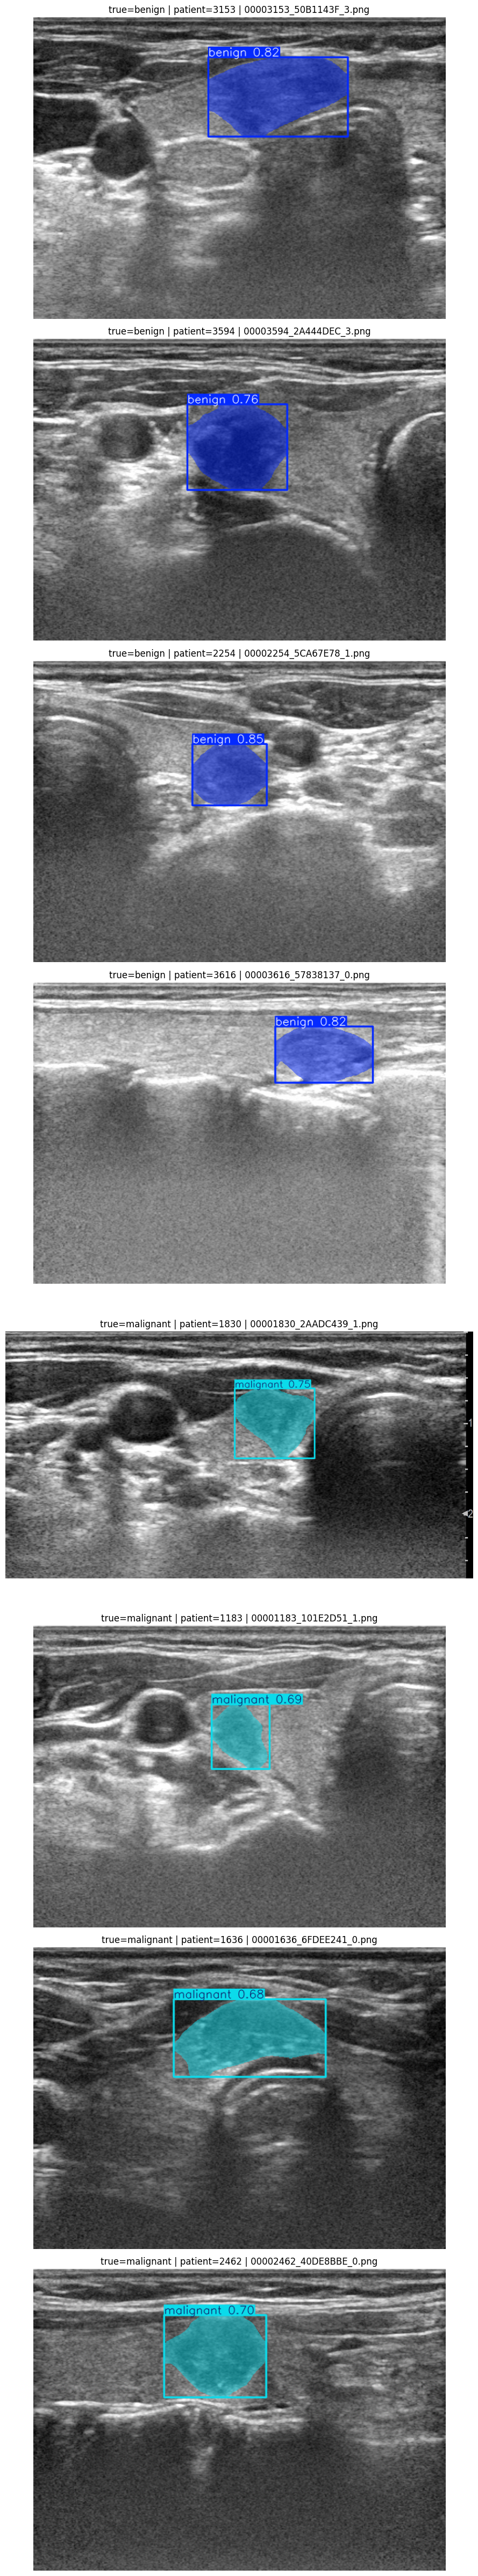

Qualitative examples were selected by fixed-seed patient sampling, not by looking for high-performing cases.


In [13]:




QUALITATIVE_PATIENTS_PER_CLASS = 4
qual_rng = np.random.default_rng(SEED + 2000)

qual_rows = []

for class_id in (0, 1):
    candidates = val_df[val_df["label"] == class_id].copy()
    unique_patients = candidates["patient_id"].drop_duplicates().to_numpy()
    chosen = qual_rng.choice(
        unique_patients,
        size=min(QUALITATIVE_PATIENTS_PER_CLASS, len(unique_patients)),
        replace=False,
    )

    for patient_id in chosen:
        qual_rows.append(
            candidates[candidates["patient_id"] == patient_id].iloc[0]
        )

qual_df = pd.DataFrame(qual_rows).reset_index(drop=True)
qual_paths = [
    str((VAL_IMAGE_DIR / filename).resolve())
    for filename in qual_df["filename"]
]

predictions = selected_model.predict(
    source=qual_paths,
    imgsz=IMAGE_SIZE,
    conf=0.25,
    iou=VALIDATION_NMS_IOU,
    device=0,
    augment=False,
    verbose=False,
)

fig, axes = plt.subplots(
    len(predictions),
    1,
    figsize=(9, 6 * len(predictions)),
    squeeze=False,
)

for idx, result in enumerate(predictions):
    rendered_bgr = result.plot()
    rendered_rgb = cv2.cvtColor(rendered_bgr, cv2.COLOR_BGR2RGB)

    row = qual_df.iloc[idx]

    axes[idx, 0].imshow(rendered_rgb)
    axes[idx, 0].set_title(
        f"true={'benign' if int(row['label']) == 0 else 'malignant'} | "
        f"patient={row['patient_id']} | {row['filename']}"
    )
    axes[idx, 0].axis("off")

plt.tight_layout()
plt.show()

print(
    "Qualitative examples were selected by fixed-seed patient sampling, "
    "not by looking for high-performing cases."
)

In [14]:




CANONICAL_SELECTED_CHECKPOINT = (
    CANONICAL_MODEL_DIR
    / f"{RUN_NAME}_selected_maskmap5095.pt"
)

shutil.copy2(
    SELECTED_CHECKPOINT,
    CANONICAL_SELECTED_CHECKPOINT,
)

def sha256_file(path):
    digest = hashlib.sha256()
    with Path(path).open("rb") as f:
        for chunk in iter(lambda: f.read(1024 * 1024), b""):
            digest.update(chunk)
    return digest.hexdigest()

manifest = {
    "status": "THYROIDXL_YOLOV8S_SEG_DEVELOPMENT_FOLD1_SELECTED",
    "study_role": "independent class-aware segmentation/localisation component",
    "dataset": "ThyroidXL",
    "dataset_repo": REPO_ID,
    "dataset_revision": REPO_REVISION,
    "official_test_accessed": False,
    "split": {
        "fold_index": FOLD_INDEX,
        "n_folds": N_FOLDS,
        "seed": SEED,
        "split_level": "patient",
        "patient_overlap_train_validation": 0,
        "training_images": int(len(train_df)),
        "validation_images": int(len(val_df)),
        "training_patients": int(train_df["patient_id"].nunique()),
        "validation_patients": int(val_df["patient_id"].nunique()),
        "training_image_class_counts": {
            str(k): int(v)
            for k, v in train_df["label"].value_counts().sort_index().to_dict().items()
        },
        "validation_image_class_counts": {
            str(k): int(v)
            for k, v in val_df["label"].value_counts().sort_index().to_dict().items()
        },
    },
    "classes": {
        "0": "benign",
        "1": "malignant",
    },
    "ground_truth": "expert PNG nodule masks converted to YOLO polygons",
    "polygon_conversion": {
        "audit_csv": str(AUDIT_CSV),
        "minimum_largest_component_retained_fraction": float(
            polygon_audit["largest_component_retained_fraction"].min()
        ),
        "minimum_polygon_reconstruction_iou": float(
            polygon_audit["polygon_reconstruction_iou"].min()
        ),
        "median_polygon_reconstruction_iou": float(
            polygon_audit["polygon_reconstruction_iou"].median()
        ),
    },
    "architecture": "YOLOv8s-seg",
    "pretraining": "COCO yolov8s-seg.pt",
    "training_configuration": {
        "image_size": IMAGE_SIZE,
        "batch_size": BATCH_SIZE,
        "epochs": EPOCHS,
        "optimizer": OPTIMIZER,
        "lr0": LEARNING_RATE,
        "lrf": FINAL_LR_FRACTION,
        "weight_decay": WEIGHT_DECAY,
        "cosine_lr": True,
        "warmup_epochs": WARMUP_EPOCHS,
        "degrees": DEGREES_ROTATION,
        "translate": TRANSLATE_IMG,
        "scale": SCALE_IMG,
        "shear": SHEAR_IMG,
        "fliplr": FLIP_LR,
        "flipud": FLIP_UD,
        "hsv_h": HSV_H,
        "hsv_s": HSV_S,
        "hsv_v": HSV_V,
        "mosaic": MOSAIC_PROBABILITY,
        "mixup": MIXUP_PROBABILITY,
        "cutmix": CUTMIX_PROBABILITY,
        "copy_paste": COPY_PASTE_PROBABILITY,
        "mask_ratio": MASK_RATIO,
        "overlap_mask": OVERLAP_MASK,
        "deterministic": True,
        "composite_augmentations_disabled": True,
    },
    "checkpoint_selection": {
        "primary_metric": PRIMARY_SELECTION_METRIC,
        "selection_source": SELECTION_SOURCE,
        "selection_dataset": "patient-disjoint Fold 1 validation only",
        "test_used_for_selection": False,
        "selected_training_epoch_one_based": int(
            SELECTED_HISTORY_ROW["epoch"]
        ),
        "selected_checkpoint_epoch_zero_based": int(
            SELECTED_HISTORY_EPOCH_ZERO_BASED
        ),
        "training_time_mask_map50_95": float(
            SELECTED_HISTORY_ROW[MASK_MAP5095_COLUMN]
        ),
        "training_time_mask_map50": float(
            SELECTED_HISTORY_ROW[MASK_MAP50_COLUMN]
        ),
        "selected_source_checkpoint": str(SELECTED_CHECKPOINT),
        "selected_validation": SELECTED_STANDARD_RECORD,
        "training_history_csv": str(PERSISTED_RESULTS_CSV),
    },
    "inference_protocol": {
        "standard_validation": SELECTED_STANDARD_RECORD,
        "tta_validation": TTA_RECORD,
        "tta_recommended": TTA_RECOMMENDED,
        "tta_error": TTA_ERROR,
        "confidence": VALIDATION_CONFIDENCE,
        "nms_iou": VALIDATION_NMS_IOU,
        "max_detections": VALIDATION_MAX_DETECTIONS,
    },
    "canonical_checkpoint": str(CANONICAL_SELECTED_CHECKPOINT),
    "canonical_sha256": sha256_file(CANONICAL_SELECTED_CHECKPOINT),
    "ultralytics_version": ultralytics.__version__,
    "torch_version": torch.__version__,
    "gpu": (
        torch.cuda.get_device_name(0)
        if torch.cuda.is_available()
        else None
    ),
}

MANIFEST_PATH = (
    CANONICAL_RESULTS_DIR
    / f"{RUN_NAME}_training_manifest.json"
)
MANIFEST_PATH.write_text(
    json.dumps(manifest, indent=2),
    encoding="utf-8",
)

FINAL_SUMMARY_CSV = (
    CANONICAL_RESULTS_DIR
    / f"{RUN_NAME}_final_validation_summary.csv"
)

summary_rows = [SELECTED_STANDARD_RECORD]
if TTA_RECORD is not None:
    summary_rows.append(TTA_RECORD)

pd.DataFrame(summary_rows).to_csv(FINAL_SUMMARY_CSV, index=False)

print("Canonical selected checkpoint:")
print(CANONICAL_SELECTED_CHECKPOINT)
print()
print("SHA-256:")
print(manifest["canonical_sha256"])
print()
print("Manifest:")
print(MANIFEST_PATH)
print()
print("Checkpoint validation table:")
print(CHECKPOINT_METRICS_CSV)
print()
print("Final validation summary:")
print(FINAL_SUMMARY_CSV)
print()
print("✅ Official ThyroidXL test split was NOT accessed.")


Canonical selected checkpoint:
/content/drive/MyDrive/ThyroidXL_Publication_OneFold/Models/YOLOv8sSeg/thyroidxl_yolov8s_seg_2class_patientfold1_640_seed42_50ep_selected_maskmap5095.pt

SHA-256:
9267578d382d0fcf279ba0712e76a8d42fec3cf0e78ca85ed3bb70ea8c99010e

Manifest:
/content/drive/MyDrive/ThyroidXL_Publication_OneFold/results/YOLOv8sSeg/thyroidxl_yolov8s_seg_2class_patientfold1_640_seed42_50ep_training_manifest.json

Checkpoint validation table:
/content/drive/MyDrive/ThyroidXL_Publication_OneFold/results/YOLOv8sSeg/thyroidxl_yolov8s_seg_2class_patientfold1_640_seed42_50ep_checkpoint_validation_metrics.csv

Final validation summary:
/content/drive/MyDrive/ThyroidXL_Publication_OneFold/results/YOLOv8sSeg/thyroidxl_yolov8s_seg_2class_patientfold1_640_seed42_50ep_final_validation_summary.csv

✅ Official ThyroidXL test split was NOT accessed.


In [15]:








SELECTED_TRAINING_EPOCH_ONE_BASED = int(
    SELECTED_HISTORY_ROW["epoch"]
)
if not 1 <= SELECTED_TRAINING_EPOCH_ONE_BASED <= EPOCHS:
    raise RuntimeError(
        "Invalid development-selected YOLO training epoch: "
        f"{SELECTED_TRAINING_EPOCH_ONE_BASED}"
    )

full_train_images = sorted(
    [*train_images, *val_images],
    key=lambda p: p.name,
)

if len(full_train_images) != EXPECTED_TRAIN_IMAGES:
    raise RuntimeError(
        f"Expected {EXPECTED_TRAIN_IMAGES} complete-training images, "
        f"got {len(full_train_images)}."
    )
if len({p.name for p in full_train_images}) != EXPECTED_TRAIN_IMAGES:
    raise RuntimeError(
        "Duplicate filename detected while combining Fold-1 train + validation."
    )



full_training_df = (
    pd.concat(
        [
            train_df.copy(),
            val_df.copy(),
        ],
        ignore_index=True,
    )
    .sort_values(
        ["patient_id", "filename"],
        key=lambda col: (
            col.astype(int)
            if col.name == "patient_id"
            else col
        ),
    )
    .reset_index(drop=True)
)

if len(full_training_df) != EXPECTED_TRAIN_IMAGES:
    raise RuntimeError("Full YOLO training frame image-count mismatch.")
if (
    full_training_df["patient_id"].nunique()
    != EXPECTED_TRAIN_PATIENTS
):
    raise RuntimeError("Full YOLO training frame patient-count mismatch.")
if full_training_df["filename"].duplicated().any():
    raise RuntimeError("Duplicate filename in full YOLO training frame.")
if (
    full_training_df.groupby("patient_id")["label"].nunique().max()
    != 1
):
    raise RuntimeError(
        "At least one patient has inconsistent labels in full training."
    )

full_patient_counts = (
    full_training_df[
        ["patient_id", "label"]
    ]
    .drop_duplicates()
    ["label"]
    .value_counts()
    .sort_index()
    .to_dict()
)
expected_full_patient_counts = {
    0: EXPECTED_TRAIN_BENIGN_PATIENTS,
    1: EXPECTED_TRAIN_MALIGNANT_PATIENTS,
}
if full_patient_counts != expected_full_patient_counts:
    raise RuntimeError(
        "Unexpected full-training patient class counts: "
        f"{full_patient_counts}"
    )

FULL_TRAIN_LIST_PATH = Path(
    "/content/thyroidxl_yolo_officialtrain9541.txt"
)
FULL_TRAIN_LIST_PATH.write_text(
    "\n".join(
        str(path.absolute())
        for path in full_train_images
    ),
    encoding="utf-8",
)

full_entries = [
    line.strip()
    for line in FULL_TRAIN_LIST_PATH.read_text(
        encoding="utf-8"
    ).splitlines()
    if line.strip()
]
mapped_full_labels = [
    Path(path)
    for path in img2label_paths(full_entries)
]
missing_full_labels = [
    str(path)
    for path in mapped_full_labels
    if not path.is_file()
]
if missing_full_labels:
    raise RuntimeError(
        "Full-refit YOLO image->label mapping failed. "
        f"Examples={missing_full_labels[:10]}"
    )

FINAL_DATA_YAML_PATH = Path(
    "/content/thyroidxl_yolov8s_seg_officialtrain9541.yaml"
)





final_data_yaml = {
    "path": str(YOLO_DATASET_ROOT),
    "train": str(FULL_TRAIN_LIST_PATH),
    "val": str(FULL_TRAIN_LIST_PATH),
    "nc": 2,
    "names": ["benign", "malignant"],
}
with FINAL_DATA_YAML_PATH.open(
    "w",
    encoding="utf-8",
) as f:
    yaml.safe_dump(
        final_data_yaml,
        f,
        sort_keys=False,
    )

checked_final_data = check_det_dataset(
    str(FINAL_DATA_YAML_PATH)
)
assert int(checked_final_data["nc"]) == 2

print("=" * 80)
print("FINAL YOLO REFIT DATASET FROZEN")
print("=" * 80)
print(
    "Complete training images:",
    len(full_training_df),
)
print(
    "Complete training patients:",
    full_training_df["patient_id"].nunique(),
)
print(
    "Development-selected epoch:",
    SELECTED_TRAINING_EPOCH_ONE_BASED,
)
print(
    "Cosine schedule horizon retained:",
    EPOCHS,
)
print("Independent validation during final refit: NO")
print("Official held-out test accessed: NO")


FINAL YOLO REFIT DATASET FROZEN
Complete training images: 9541
Complete training patients: 3354
Development-selected epoch: 16
Cosine schedule horizon retained: 50
Independent validation during final refit: NO
Official held-out test accessed: NO


In [16]:











FINAL_STATUS = (
    "THYROIDXL_YOLO_FINAL_OFFICIAL_TRAIN_REFIT_ONEFOLD_SELECTED"
)
FINAL_RUN_NAME = (
    f"thyroidxl_yolov8s_seg_officialtrain9541_"
    f"onefoldselected_{IMAGE_SIZE}_seed{SEED}_final"
)
FINAL_YOLO_RUN_ROOT = Path(
    "/content/thyroidxl_yolo_final_refit_runs"
)


random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
torch.cuda.empty_cache()

final_yolo_model = YOLO("yolov8s-seg.pt")

final_training_results = final_yolo_model.train(
    data=str(FINAL_DATA_YAML_PATH),


    epochs=EPOCHS,
    imgsz=IMAGE_SIZE,
    batch=BATCH_SIZE,
    nbs=64,

    project=str(FINAL_YOLO_RUN_ROOT),
    name=FINAL_RUN_NAME,
    exist_ok=False,

    optimizer=OPTIMIZER,
    lr0=LEARNING_RATE,
    lrf=FINAL_LR_FRACTION,
    weight_decay=WEIGHT_DECAY,
    cos_lr=True,
    warmup_epochs=WARMUP_EPOCHS,

    degrees=DEGREES_ROTATION,
    translate=TRANSLATE_IMG,
    scale=SCALE_IMG,
    shear=SHEAR_IMG,
    perspective=PERSPECTIVE_IMG,

    fliplr=FLIP_LR,
    flipud=FLIP_UD,

    hsv_h=HSV_H,
    hsv_s=HSV_S,
    hsv_v=HSV_V,

    mosaic=MOSAIC_PROBABILITY,
    close_mosaic=0,
    mixup=MIXUP_PROBABILITY,
    cutmix=CUTMIX_PROBABILITY,
    copy_paste=COPY_PASTE_PROBABILITY,

    mask_ratio=MASK_RATIO,
    overlap_mask=OVERLAP_MASK,


    val=False,
    patience=EPOCHS,

    amp=True,
    workers=8,
    cache=False,
    rect=False,

    seed=SEED,
    deterministic=True,
    device=0,

    plots=False,
    save=True,
    save_period=1,
)

FINAL_RUN_DIRECTORY = Path(
    final_yolo_model.trainer.save_dir
)
FINAL_WEIGHTS_DIRECTORY = (
    FINAL_RUN_DIRECTORY / "weights"
)

selected_zero_based = (
    SELECTED_TRAINING_EPOCH_ONE_BASED - 1
)
selected_final_source = (
    FINAL_WEIGHTS_DIRECTORY
    / f"epoch{selected_zero_based}.pt"
)


if (
    not selected_final_source.is_file()
    and SELECTED_TRAINING_EPOCH_ONE_BASED == EPOCHS
):
    selected_final_source = (
        FINAL_WEIGHTS_DIRECTORY / "last.pt"
    )

if not selected_final_source.is_file():
    available = sorted(
        p.name
        for p in FINAL_WEIGHTS_DIRECTORY.glob("*.pt")
    )
    raise RuntimeError(
        "Could not locate the preselected final-refit checkpoint "
        f"for epoch {SELECTED_TRAINING_EPOCH_ONE_BASED}. "
        f"Available={available[:30]}"
    )

CANONICAL_FINAL_CHECKPOINT = (
    CANONICAL_MODEL_DIR
    / f"{FINAL_RUN_NAME}.pt"
)
shutil.copy2(
    selected_final_source,
    CANONICAL_FINAL_CHECKPOINT,
)

print("=" * 80)
print("FINAL YOLO REFIT COMPLETE")
print("=" * 80)
print(
    "Selected development epoch:",
    SELECTED_TRAINING_EPOCH_ONE_BASED,
)
print(
    "Final source checkpoint:",
    selected_final_source,
)
print(
    "Canonical final checkpoint:",
    CANONICAL_FINAL_CHECKPOINT,
)
print("Official held-out test accessed: NO")


New https://pypi.org/project/ultralytics/8.4.128 available 😃 Update with 'pip install -U ultralytics'
Ultralytics 8.4.115 🚀 Python-3.13.15 torch-2.11.0+cu128 CUDA:0 (NVIDIA L4, 22563MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=8, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=False, classes=None, close_mosaic=0, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=True, cutmix=0.0, data=/content/thyroidxl_yolov8s_seg_officialtrain9541.yaml, degrees=7.5, deterministic=True, device=0, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.0, hsv_s=0.0, hsv_v=0.08, imgsz=640, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.0005, lrf=0.1, mask_ratio=2, max_det=300

In [17]:




FINAL_CHECKPOINT_SHA256 = sha256_file(
    CANONICAL_FINAL_CHECKPOINT
)

FINAL_RESULTS_CSV_SOURCE = (
    FINAL_RUN_DIRECTORY / "results.csv"
)
FINAL_RESULTS_CSV_PERSISTED = (
    CANONICAL_RESULTS_DIR
    / f"{FINAL_RUN_NAME}_training_history.csv"
)

if FINAL_RESULTS_CSV_SOURCE.is_file():
    shutil.copy2(
        FINAL_RESULTS_CSV_SOURCE,
        FINAL_RESULTS_CSV_PERSISTED,
    )
else:
    FINAL_RESULTS_CSV_PERSISTED = None

final_manifest = {
    "status": FINAL_STATUS,
    "publication_role": (
        "final fresh YOLOv8s-seg refit on the complete official "
        "ThyroidXL training cohort after Fold-1 development selection"
    ),
    "dataset": "ThyroidXL",
    "dataset_repo": REPO_ID,
    "dataset_revision": REPO_REVISION,
    "official_test_accessed": False,

    "training_images": int(
        len(full_training_df)
    ),
    "training_patients": int(
        full_training_df["patient_id"].nunique()
    ),
    "training_patient_class_counts": {
        str(k): int(v)
        for k, v in full_patient_counts.items()
    },



    "internal_validation_used_in_final_refit": False,
    "independent_validation_used_in_final_refit": False,
    "validation_used_for_final_checkpoint_selection": False,
    "automatic_final_training_set_diagnostic_used_for_selection": False,

    "selection_source": {
        "split_level": "patient",
        "fold_index": int(FOLD_INDEX),
        "n_folds": int(N_FOLDS),
        "patient_split_seed": int(SEED),
        "training_images": int(len(train_df)),
        "training_patients": int(
            train_df["patient_id"].nunique()
        ),
        "validation_images": int(len(val_df)),
        "validation_patients": int(
            val_df["patient_id"].nunique()
        ),
        "patient_overlap": 0,
        "test_used_for_selection": False,
        "checkpoint_selection_metric": (
            PRIMARY_SELECTION_METRIC
        ),
        "selection_source": SELECTION_SOURCE,
        "selected_training_epoch_one_based": int(
            SELECTED_TRAINING_EPOCH_ONE_BASED
        ),
        "selected_checkpoint_epoch_zero_based": int(
            SELECTED_TRAINING_EPOCH_ONE_BASED - 1
        ),
        "development_training_time_mask_map50_95": float(
            SELECTED_HISTORY_ROW[
                MASK_MAP5095_COLUMN
            ]
        ),
        "development_training_time_mask_map50": float(
            SELECTED_HISTORY_ROW[
                MASK_MAP50_COLUMN
            ]
        ),
    },

    "architecture": "YOLOv8s-seg",
    "pretraining": "COCO yolov8s-seg.pt",

    "training_configuration": {
        "image_size": int(IMAGE_SIZE),
        "batch_size": int(BATCH_SIZE),

        "epochs": int(EPOCHS),
        "schedule_horizon_epochs": int(EPOCHS),
        "selected_publication_checkpoint_epoch_one_based": int(
            SELECTED_TRAINING_EPOCH_ONE_BASED
        ),
        "optimizer": OPTIMIZER,
        "lr0": float(LEARNING_RATE),
        "lrf": float(FINAL_LR_FRACTION),
        "weight_decay": float(WEIGHT_DECAY),
        "cosine_lr": True,
        "warmup_epochs": float(WARMUP_EPOCHS),
        "degrees": float(DEGREES_ROTATION),
        "translate": float(TRANSLATE_IMG),
        "scale": float(SCALE_IMG),
        "shear": float(SHEAR_IMG),
        "perspective": float(PERSPECTIVE_IMG),
        "fliplr": float(FLIP_LR),
        "flipud": float(FLIP_UD),
        "hsv_h": float(HSV_H),
        "hsv_s": float(HSV_S),
        "hsv_v": float(HSV_V),
        "mosaic": float(MOSAIC_PROBABILITY),
        "mixup": float(MIXUP_PROBABILITY),
        "cutmix": float(CUTMIX_PROBABILITY),
        "copy_paste": float(
            COPY_PASTE_PROBABILITY
        ),
        "mask_ratio": int(MASK_RATIO),
        "overlap_mask": bool(
            OVERLAP_MASK
        ),
        "deterministic": True,
        "amp": True,
    },


    "inference_protocol": {
        "confidence": float(
            VALIDATION_CONFIDENCE
        ),
        "nms_iou": float(
            VALIDATION_NMS_IOU
        ),
        "max_detections": int(
            VALIDATION_MAX_DETECTIONS
        ),
        "tta_recommended": False,
        "retina_masks_for_original_geometry_evaluation": True,
    },

    "development_checkpoint": str(
        CANONICAL_SELECTED_CHECKPOINT
    ),
    "development_checkpoint_sha256": sha256_file(
        CANONICAL_SELECTED_CHECKPOINT
    ),

    "checkpoint": str(
        CANONICAL_FINAL_CHECKPOINT
    ),
    "final_checkpoint_sha256": (
        FINAL_CHECKPOINT_SHA256
    ),
    "checkpoint_sha256": (
        FINAL_CHECKPOINT_SHA256
    ),

    "final_training_history_csv": (
        str(FINAL_RESULTS_CSV_PERSISTED)
        if FINAL_RESULTS_CSV_PERSISTED is not None
        else None
    ),

    "ultralytics_version": (
        ultralytics.__version__
    ),
    "torch_version": torch.__version__,
    "gpu": (
        torch.cuda.get_device_name(0)
        if torch.cuda.is_available()
        else None
    ),

    "methodological_note": (
        "Model/epoch selection was performed only on the patient-disjoint "
        "Fold-1 validation partition. A fresh COCO-initialized model was "
        "then trained on all 9,541 official-training images using the same "
        "50-epoch cosine schedule. The publication checkpoint is the "
        "already-selected epoch from that refit; later full-training epochs "
        "are ignored for model selection. The official held-out cohort was "
        "not accessed by this notebook."
    ),
}

FINAL_MANIFEST_PATH = (
    CANONICAL_RESULTS_DIR
    / f"{FINAL_RUN_NAME}_training_manifest.json"
)
FINAL_MANIFEST_PATH.write_text(
    json.dumps(
        final_manifest,
        indent=2,
    ),
    encoding="utf-8",
)

print("=" * 80)
print("FINAL YOLO PUBLICATION MODEL SAVED")
print("=" * 80)
print(
    "Checkpoint:",
    CANONICAL_FINAL_CHECKPOINT,
)
print(
    "SHA256:",
    FINAL_CHECKPOINT_SHA256,
)
print(
    "Manifest:",
    FINAL_MANIFEST_PATH,
)
if FINAL_RESULTS_CSV_PERSISTED is not None:
    print(
        "Training history:",
        FINAL_RESULTS_CSV_PERSISTED,
    )
print()
print("✅ Official ThyroidXL held-out test split was NOT accessed.")


FINAL YOLO PUBLICATION MODEL SAVED
Checkpoint: /content/drive/MyDrive/ThyroidXL_Publication_OneFold/Models/YOLOv8sSeg/thyroidxl_yolov8s_seg_officialtrain9541_onefoldselected_640_seed42_final.pt
SHA256: a9dcd76aa76fa91ae2b9d61820fdd53a06df7e98f10efb5bb2dea8efdc01e92b
Manifest: /content/drive/MyDrive/ThyroidXL_Publication_OneFold/results/YOLOv8sSeg/thyroidxl_yolov8s_seg_officialtrain9541_onefoldselected_640_seed42_final_training_manifest.json
Training history: /content/drive/MyDrive/ThyroidXL_Publication_OneFold/results/YOLOv8sSeg/thyroidxl_yolov8s_seg_officialtrain9541_onefoldselected_640_seed42_final_training_history.csv

✅ Official ThyroidXL held-out test split was NOT accessed.
